AARIS-Lite: Academic Analytics & Recommendation System

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import r2_score, mean_squared_error

In [11]:
import os
print(os.getcwd())

C:\Users\HONOR\Downloads


In [41]:
path = r"C:\Users\HONOR\Download\data\Grade"

In [46]:
import os
os.listdir("data")

['.ipynb_checkpoints',
 'AARIS_Notebook (1).ipynb',
 'cleaned_Grade.csv',
 'data.csv',
 'Grade.ipynb']

In [49]:
df = pd.read_csv("data/cleaned_Grade.csv")
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (335, 68)
  Year of enrolment   ID  CS101  CS102  MA101      MA112  MA121  GS101  GS102  \
0         2005-2008  ST1     40     51     40  47.583893     40     44     57   
1         2005-2008  ST2     40     40     46  47.583893     40     48     45   
2         2005-2008  ST3     53     77     45  47.583893     40     48     50   
3         2005-2008  ST4     40     41     40  47.583893     40     40     44   
4         2005-2008  ST5     51     52     50  47.583893     40     67     54   

   PH101  ...  CS507  CS508  CS509  CS510  CS512  CS597  CS598  MA419  SW499  \
0     40  ...     50   42.0   67.0   46.0   43.0   63.0   70.0   58.0   63.0   
1     40  ...     41   40.0   49.0   40.0   40.0   60.0   70.0   69.0   70.0   
2     40  ...     54   41.0   67.0   41.0   40.0   62.0   76.0   63.0   66.0   
3     40  ...     44   56.0   55.0   40.0   40.0   66.0   64.0   46.0   66.0   
4     40  ...     52   40.0   40.0   64.0   43.0   60.0   71.0   51.0   66.0   

       

In [50]:
df["Year of enrolment"] = df["Year of enrolment"].ffill()

 DATA RESHAPING (WIDE → LONG FORMAT)

In [51]:
id_vars=["Year of enrolment", "ID"]
long_df = df.melt(
    id_vars=id_vars,
    var_name="Course",
    value_name="Score"
)
print("Reshaped Data:")
print(long_df.head())

Reshaped Data:
  Year of enrolment   ID Course  Score
0         2005-2008  ST1  CS101   40.0
1         2005-2008  ST2  CS101   40.0
2         2005-2008  ST3  CS101   53.0
3         2005-2008  ST4  CS101   40.0
4         2005-2008  ST5  CS101   51.0


In [52]:
long_df = long_df.dropna()

SCORE - GRADE

In [53]:
def assign_grade(score):
    if score >= 70:
        return "A"
    elif score >= 60:
        return "B"
    elif score >= 50:
        return "C"
    elif score >= 45:
        return "D"
    elif score >= 40:
        return "E"
    else:
        return "F"
    
long_df["Grade"] = long_df["Score"].apply(assign_grade)

GRADE-GRADE POINTS

In [54]:
grade_points = {
"A":5,
"B":4,
"C":3,
"D":2,
"E":1,
"F":0

}

long_df["GradePoint"] = long_df["Grade"].map(grade_points)

GPA CALCULATION

In [55]:
gpa_df = long_df.groupby("ID")["GradePoint"].mean().reset_index()
gpa_df.rename(columns={"GradePoint":"GPA"}, inplace=True)
print("GPA Sample")
print(gpa_df.head())

GPA Sample
      ID       GPA
0    ST1  2.393939
1   ST10  2.469697
2  ST100  2.363636
3  ST101  2.621212
4  ST102  2.181818


CGPA CALCULATION

In [56]:
gpa_df["CGPA"] = gpa_df["GPA"].expanding().mean()
print("CGPA Sample")
print(gpa_df.head())

CGPA Sample
      ID       GPA      CGPA
0    ST1  2.393939  2.393939
1   ST10  2.469697  2.431818
2  ST100  2.363636  2.409091
3  ST101  2.621212  2.462121
4  ST102  2.181818  2.406061


In [84]:
#To Check Cohort Performance

In [85]:
# Create a small lookup table with just ID and Year
cohort_info = long_df[["ID" , "Year of enrolment"]].drop_duplicates()

#Merge it with your new gpa_df
cohort_gpa= pd.merge(gpa_df, cohort_info, on="ID")

print(cohort_gpa.head())

      ID       GPA      CGPA Year of enrolment
0    ST1  2.393939  2.393939         2005-2008
1   ST10  2.469697  2.469697         2005-2008
2  ST100  2.363636  2.363636         2010-2011
3  ST101  2.621212  2.621212         2010-2011
4  ST102  2.181818  2.181818         2010-2011


EXPLORATORY DATA ANALYSIS

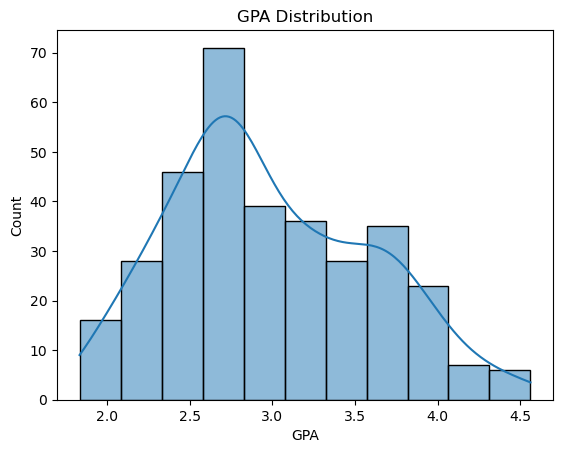

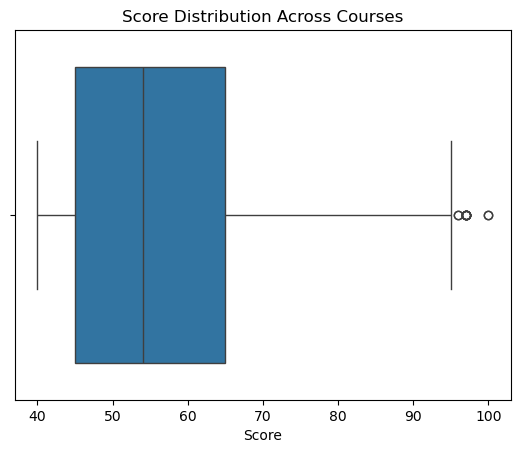

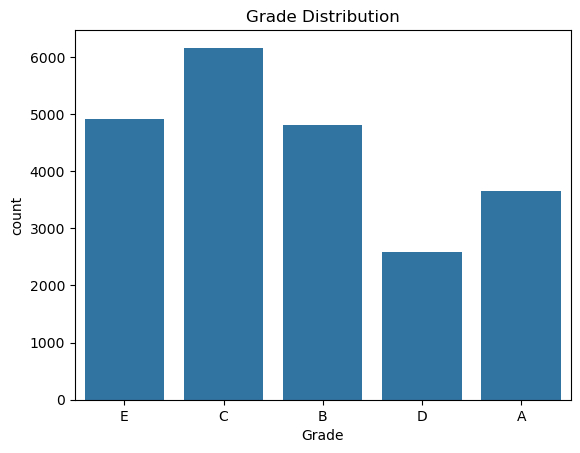

C:\Users\HONOR\AppData\Local\Temp\ipykernel_21956\1777691756.py:16: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=cohort_gpa, x="Year of enrolment", y="GPA", palette="Set2", marker="o")


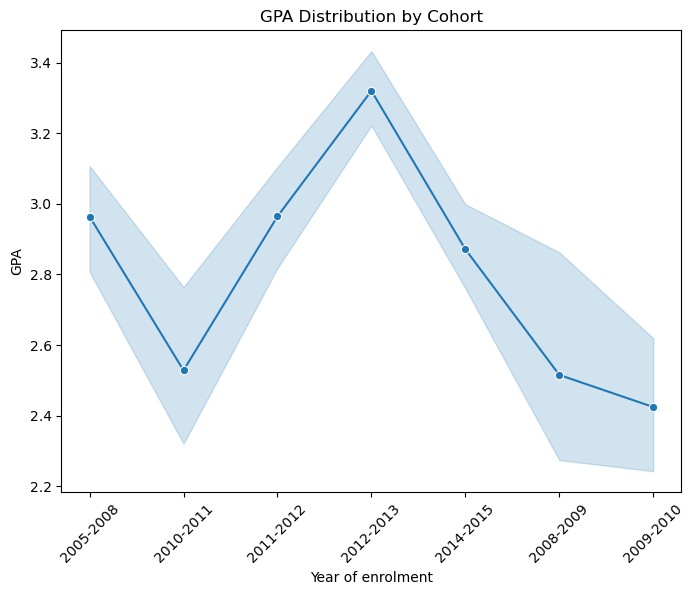

In [82]:
plt.figure()
sns.histplot(gpa_df["GPA"], kde=True)
plt.title("GPA Distribution")
plt.show()

plt.figure()
sns.boxplot(x=long_df["Score"])
plt.title("Score Distribution Across Courses")
plt.show()
plt.figure()
sns.countplot(x=long_df["Grade"])
plt.title("Grade Distribution")
plt.show()

plt.figure(figsize=(8,6))
sns.lineplot(data=cohort_gpa, x="Year of enrolment", y="GPA", palette="Set2", marker="o")
plt.title("GPA Distribution by Cohort")
plt.xticks(rotation=45)
plt.show()            

 ANOMALY DETECTION (ISOLATION FOREST)

In [86]:
features_anomaly = long_df[["Score","GradePoint"]]
iso = IsolationForest(contamination=0.05, random_state=42)
long_df["Anomaly"] = iso.fit_predict(features_anomaly)
long_df["Anomaly"] = long_df["Anomaly"].apply(lambda x: 1 if x==-1 else 0)
print("Anomaly Counts")
print(long_df["Anomaly"].value_counts())

Anomaly Counts
Anomaly
0    21155
1      955
Name: count, dtype: int64


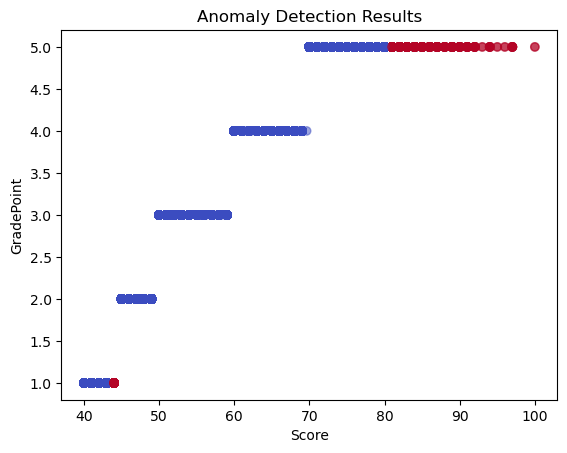

In [112]:
plt.scatter(long_df["Score"], long_df["GradePoint"],
            c=long_df["Anomaly"], cmap="coolwarm", alpha= 0.5)
plt.xlabel("Score")
plt.ylabel("GradePoint")
plt.title("Anomaly Detection Results")
plt.show()

Student Performance Statistics

In [87]:
stats_df = long_df.groupby("ID")["Score"].agg(

    Score="mean",
    MaxScore="max",
    MinScore="min",
    ScoreVar="var"

).reset_index()

course_count = long_df.groupby("ID").size().reset_index(name="CourseCount")
stats_df = stats_df.merge(course_count, on="ID")

gpa_df = long_df.groupby("ID")["GradePoint"].mean().reset_index()
gpa_df.rename(columns={"GradePoint":"GPA"}, inplace=True)

gpa_df["CGPA"] = gpa_df.groupby("ID")["GPA"].transform("mean")
model_df = stats_df.merge(gpa_df, on="ID")
print("Model Data Sample:")
print(model_df.head())
print(model_df.shape)

Model Data Sample:
      ID      Score  MaxScore  MinScore    ScoreVar  CourseCount       GPA  \
0    ST1  50.243985      75.0      40.0   93.027832           66  2.393939   
1   ST10  51.582740      79.0      40.0  114.585254           66  2.469697   
2  ST100  50.393939      81.0      40.0   86.765501           66  2.363636   
3  ST101  52.909091      80.0      40.0  103.006993           66  2.621212   
4  ST102  48.954545      77.0      40.0  108.474825           66  2.181818   

       CGPA  
0  2.393939  
1  2.469697  
2  2.363636  
3  2.621212  
4  2.181818  
(335, 8)


In [88]:
X_reg = model_df[[
    "Score",
    "MaxScore",
    "MinScore",
    "ScoreVar",
    "CourseCount"
    ]]
y_reg = model_df["CGPA"]

LINEAR REGRESSION (PREDICT CGPA)

Linear Regression Performance
R2: 0.9901053439179317
RMSE: 0.05757986986842492


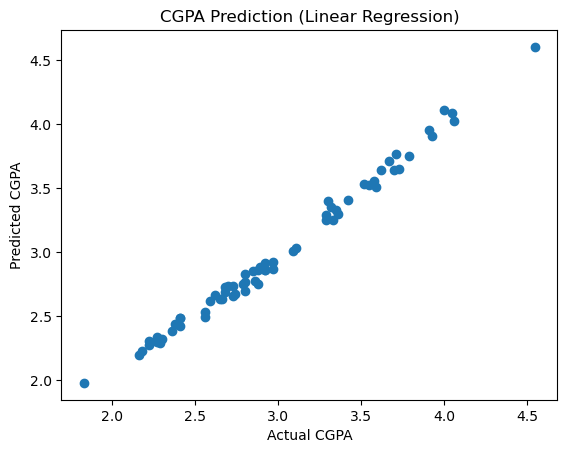

In [89]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42

)

lr = LinearRegression()
lr.fit(X_train_reg, y_train_reg)
pred_reg = lr.predict(X_test_reg)
print("Linear Regression Performance")
print("R2:", r2_score(y_test_reg, pred_reg))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, pred_reg)))
plt.figure()
plt.scatter(y_test_reg, pred_reg)
plt.xlabel("Actual CGPA")
plt.ylabel("Predicted CGPA")
plt.title("CGPA Prediction (Linear Regression)")
plt.show()

In [90]:
train_pred = lr.predict(X_train_reg)

print("Train R2:", r2_score(y_train_reg, train_pred))
print("Test R2:", r2_score(y_test_reg, pred_reg))

Train R2: 0.9912813126422806
Test R2: 0.9901053439179317


In [91]:
print(model_df.head())

      ID      Score  MaxScore  MinScore    ScoreVar  CourseCount       GPA  \
0    ST1  50.243985      75.0      40.0   93.027832           66  2.393939   
1   ST10  51.582740      79.0      40.0  114.585254           66  2.469697   
2  ST100  50.393939      81.0      40.0   86.765501           66  2.363636   
3  ST101  52.909091      80.0      40.0  103.006993           66  2.621212   
4  ST102  48.954545      77.0      40.0  108.474825           66  2.181818   

       CGPA  
0  2.393939  
1  2.469697  
2  2.363636  
3  2.621212  
4  2.181818  


CLASSIFICATION TARGET


In [92]:
model_df["GoodStanding"] = model_df["CGPA"].apply(lambda x: 1 if x>=2.5 else 0)

RANDOM FOREST CLASSIFICATION

In [95]:
X = model_df[["Score", "MaxScore", "MinScore", "ScoreVar","CourseCount"]]
y = model_df["GoodStanding"]

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42

)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
print("Confusion Matrix")
print(confusion_matrix(y_test,pred))
print("Classification Report")
print(classification_report(y_test,pred))

Confusion Matrix
[[15  0]
 [ 0 52]]
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        52

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



FEATURE IMPORTANCE

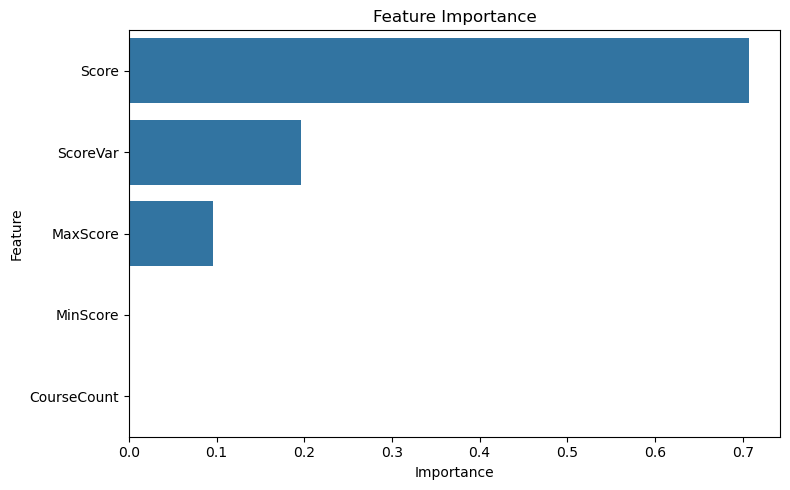

In [96]:
importance_df = pd.DataFrame
import seaborn as sns

importance_df = pd.DataFrame({
    "Feature": X_train_reg.columns,
    "Importance": rf.feature_importances_
})
importance_df = importance_df.sort_values(by="Importance", ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=importance_df, x="Importance",y="Feature")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

SHAP EXPLAINABILITY

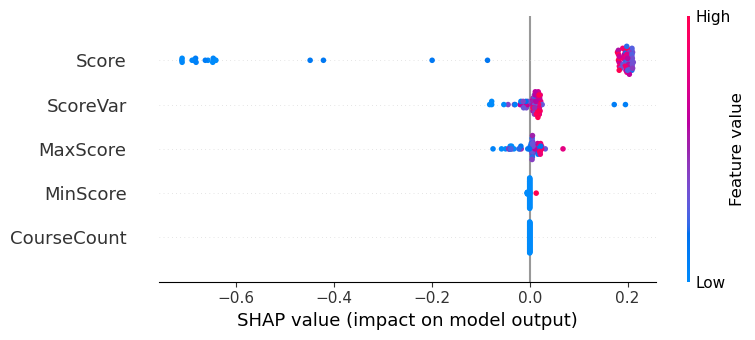

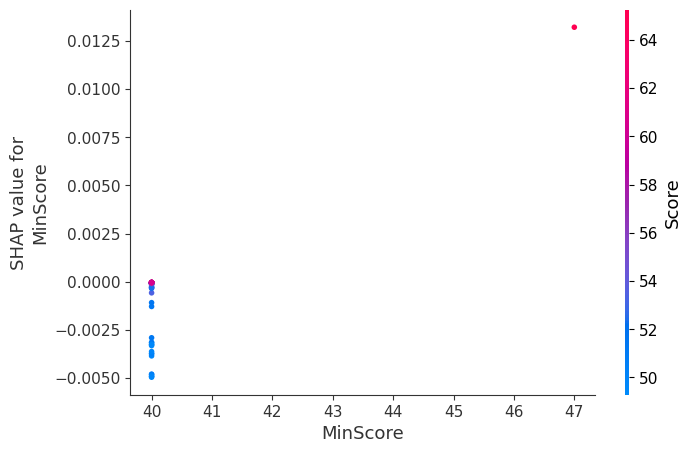

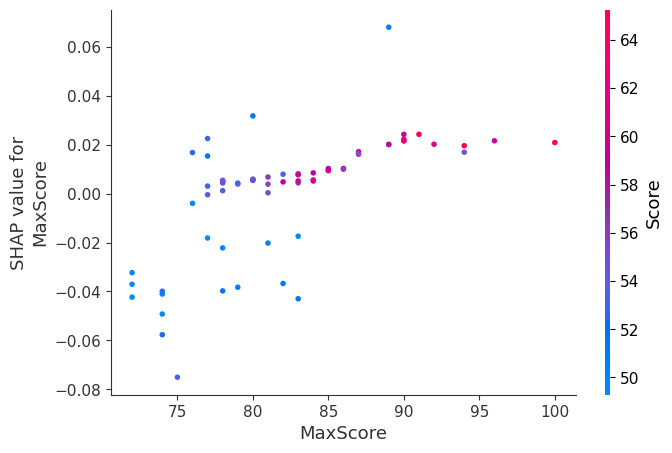

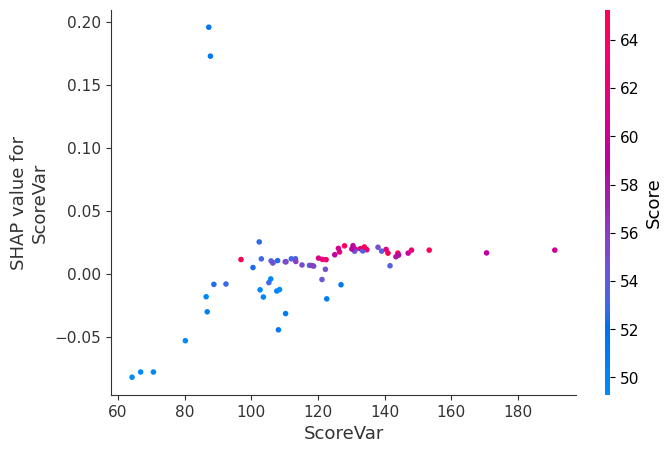

In [102]:
import shap

explainer = shap.TreeExplainer(rf, X_train_reg)
shap_values = explainer.shap_values(X_test_reg)

shap_values = shap_values[:, :, 1]
shap.summary_plot(shap_values, X_test_reg)
shap.dependence_plot("MinScore", shap_values, X_test_reg)
shap.dependence_plot("MaxScore", shap_values, X_test_reg)
shap.dependence_plot("ScoreVar", shap_values, X_test_reg)

IDENTIFYING "AT-RISK" STUDENTS 

In [104]:
risk_impact = shap_values.sum(axis=1)

risk_results = pd.DataFrame({
    "Student_Index": X_test_reg.index,
    "Model_Risk_Impact": risk_impact
})

high_risk_students = risk_results.sort_values(by="Model_Risk_Impact").head(10)
print('Top 10 Students Flagged by the Model as "AT Risk":')
print(high_risk_students)

Top 10 Students Flagged by the Model as "AT Risk":
    Student_Index  Model_Risk_Impact
24              5            -0.7763
23            325            -0.7663
44            330            -0.7563
35            310            -0.7563
2              76            -0.7563
16             75            -0.7563
15            202            -0.7463
17            318            -0.7463
20            111            -0.7363
13            316            -0.7363


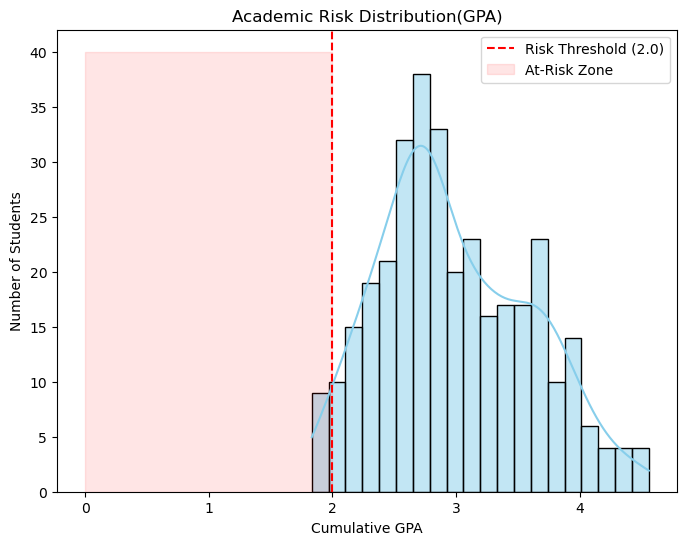

In [109]:
risk_threshold = 2.0
plt.figure(figsize= (8,6))

sns.histplot(gpa_df["GPA"],bins=20, kde=True, color="skyblue")
plt.axvline(risk_threshold, color="red", linestyle= '--', label= f'Risk Threshold ({risk_threshold})') 

plt.fill_between([0, risk_threshold], 0, 40, color='red', alpha=0.1, label='At-Risk Zone')

plt.title("Academic Risk Distribution(GPA)")
plt.xlabel("Cumulative GPA")
plt.ylabel("Number of Students")
plt.legend()
plt.show()
          

RECOMMENDATION ENGINE

In [113]:
def recommendation(gpa):
    if gpa >= 4:
        return "Excellent performance. Maintain strong study habits."
    elif gpa >= 3:
        return "Good performance. Increase revision before exams."
    elif gpa >= 2:
        return "Average performance. Increase study hours."
    else:
        return "Poor performance. Seek academic mentoring."
model_df["Recommendation"] = model_df["GPA"].apply(recommendation)
print(model_df[["ID","GPA","CGPA","Recommendation"]].head())

      ID       GPA      CGPA                              Recommendation
0    ST1  2.393939  2.393939  Average performance. Increase study hours.
1   ST10  2.469697  2.469697  Average performance. Increase study hours.
2  ST100  2.363636  2.363636  Average performance. Increase study hours.
3  ST101  2.621212  2.621212  Average performance. Increase study hours.
4  ST102  2.181818  2.181818  Average performance. Increase study hours.


OUTPUT

In [114]:
model_df.to_csv("AARIS_results.csv", index=False)
print("AARIS analysis completed successfully.")

AARIS analysis completed successfully.


In [115]:
print(model_df["GoodStanding"]. value_counts(normalize=True))

GoodStanding
1    0.78806
0    0.21194
Name: proportion, dtype: float64


In [116]:
import pickle
import os 
os.makedirs("../app", exist_ok=True)
with open("../app/regression_model.pkl", "wb") as f:
    pickle.dump(lr, f)
with open("../app/classifier_model.pkl", "wb") as f:
    pickle.dump(rf, f)
with open("../app/anomaly_model.pkl", "wb") as f:
    pickle.dump(iso, f)
print("Models saved successfully!")

Models saved successfully!
